# Feature Engineering

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load Preprocessed Data

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
X_train = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Day11/x_train_preprocessed.csv")
X_test = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Day11/x_test_preprocessed.csv")

y_train = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Day11/y_train_preprocessed.csv")
y_test = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Day11/y_test_preprocessed.csv")

print(X_train.shape)
print(y_train.shape)

(279, 3)
(279, 1)


In [4]:
print(X_train.head())

print("\nColumns:")
print(X_train.columns)

   Analog value  Analog Voltage       NTU
0     -0.895865       -0.895865  1.509531
1      0.996565        0.996565 -1.360378
2     -0.750293       -0.750293  1.509531
3     -0.556198       -0.556198  1.509531
4      1.142136        1.142136 -1.360378

Columns:
Index(['Analog value', 'Analog Voltage', 'NTU'], dtype='object')


## 2. Feature Importance

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train.values.ravel()
)

RandomForestClassifier(random_state=42)

## 3. Feature Importance Table

In [6]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

          Feature  Importance
1  Analog Voltage    0.452091
0    Analog value    0.436741
2             NTU    0.111168


## 4. Plot Feature Importance

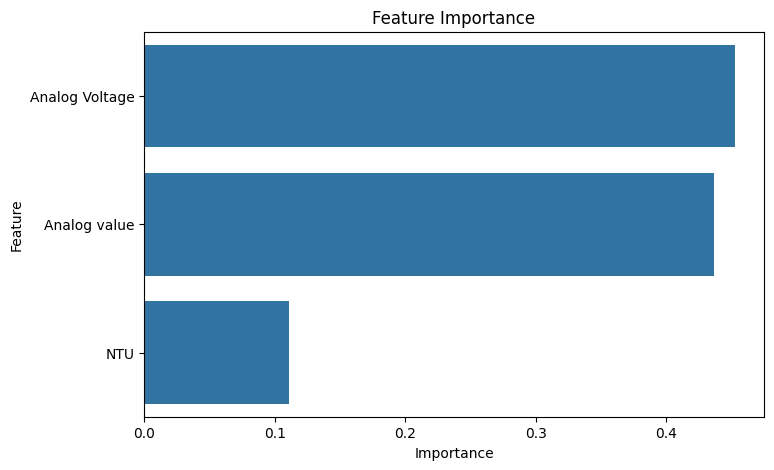

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

## 5. Correlation Analysis

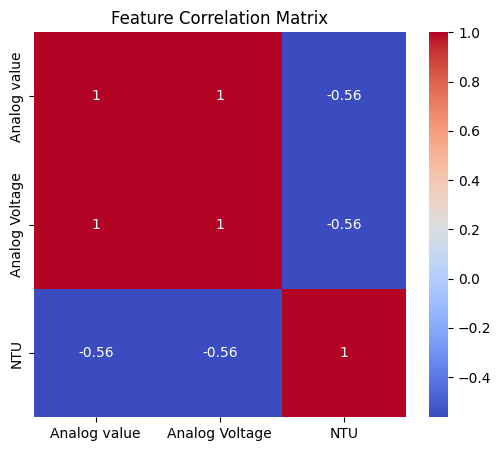

In [11]:
plt.figure(figsize=(6,5))

sns.heatmap(
    X_train.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

## 6. Variance Analysis

In [12]:
variance = pd.DataFrame({
    "Feature": X_train.columns,
    "Variance": X_train.var()
})

print(variance)

                       Feature  Variance
Analog value      Analog value  1.003597
Analog Voltage  Analog Voltage  1.003597
NTU                        NTU  1.003597
